# CSI4142 Assignment 2
Jonathan Cojita, Lucas Gavura

## Part 1: Validation Checking
Lucas Gavura

In [274]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

In [275]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "ranaghulamnabi/us-top-50-universities-2026-rankings-and-key-metrics"
)

df = pd.read_csv(f"{path}/US_Top_50_Universities_2026.csv")
df_original = df.copy()
print(df.head())

                               University_Name  National_Rank  Founded_Year  \
0  Massachusetts Institute of Technology (MIT)              1          1861   
1                          Columbia University              2          1754   
2                         Princeton University              3          1746   
3                          Stanford University              4          1891   
4           University of California, Berkeley              5          1868   

  Institution_Type State  Research_Impact_Score  Intl_Student_Ratio  \
0          Private    MA                  100.0                91.6   
1          Private    NY                   95.9                83.7   
2          Private    NJ                   99.0                70.0   
3          Private    CA                   99.5                73.5   
4           Public    CA                   98.9                70.6   

   Employment_Rate  
0             96.2  
1             92.1  
2             94.5  
3             

### 1.1:
**Data Type Errors**

This test verifies the values in the columns match their expected data types, we will ensure that the column for integers doesn't contain any strings or other incompatible data types.


In [276]:
df['National_Rank'] = df['National_Rank'].astype(object)
rows = df.sample(frac=0.06, random_state=1).index
df.loc[rows, 'National_Rank'] = "Error"

In [277]:
type_errors = df[~pd.to_numeric(df['National_Rank'], errors='coerce').notnull()]

print("Number of Data Type Errors:", len(type_errors))
type_errors.head()

Number of Data Type Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
27,University of Southern California (USC),Error,1880,Private,CA,91.5,25.4,89.7
35,Pomona College,Error,1887,Private,CA,34.5,11.8,87.9
40,Georgetown University,Error,1789,Private,DC,78.4,18.9,90.3


In [278]:
original_rows = df_original.loc[type_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(type_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
27,University of Southern California (USC),28,1880,Private,CA,91.5,25.4,89.7
35,Pomona College,36,1887,Private,CA,34.5,11.8,87.9
40,Georgetown University,41,1789,Private,DC,78.4,18.9,90.3



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
27,University of Southern California (USC),Error,1880,Private,CA,91.5,25.4,89.7
35,Pomona College,Error,1887,Private,CA,34.5,11.8,87.9
40,Georgetown University,Error,1789,Private,DC,78.4,18.9,90.3


### 1.2:
**Range Errors**

This test we will verify the range of a numeritical value and ensure it falls within a logical range, so in this test we will ensure the research impact score stays within 0-100.


In [279]:
rows = df.sample(frac=0.06, random_state=2).index
df.loc[rows, 'Research_Impact_Score'] = -10

In [280]:
range_errors = df[(df['Research_Impact_Score'] < 0) | (df['Research_Impact_Score'] > 100)]
print("Number of Range Errors:", len(range_errors))
range_errors

Number of Range Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
28,Wellesley College,29,1870,Private,MA,-10.0,12.5,85.2
36,"University of Maryland, College Park",37,1856,Public,MD,-10.0,18.2,82.1
47,Colgate University,48,1819,Private,NY,-10.0,8.4,88.1


In [281]:
original_rows = df_original.loc[range_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(range_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
28,Wellesley College,29,1870,Private,MA,32.1,12.5,85.2
36,"University of Maryland, College Park",37,1856,Public,MD,86.4,18.2,82.1
47,Colgate University,48,1819,Private,NY,30.2,8.4,88.1



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
28,Wellesley College,29,1870,Private,MA,-10.0,12.5,85.2
36,"University of Maryland, College Park",37,1856,Public,MD,-10.0,18.2,82.1
47,Colgate University,48,1819,Private,NY,-10.0,8.4,88.1


### 1.3:
**Format errors**

This test verifies the strings following specific formats follow them. We will ensure institution type is in the format of public or private.


In [282]:

rows = df.sample(frac=0.06, random_state=3).index
df.loc[rows, 'Institution_Type'] = "priv"

In [283]:
valid_types = ["Public", "Private"]

format_errors = df[
    ~df['Institution_Type'].isin(valid_types)
]

print("Number of Format Errors Detected:", len(format_errors))
display(format_errors.head(3))

Number of Format Errors Detected: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
9,University of Pennsylvania,10,1740,priv,PA,96.1,76.3,94.8
12,University of Chicago,13,1890,priv,IL,96.8,92.8,91.2
39,Brigham Young University,40,1875,priv,UT,45.2,5.1,84.4


In [284]:
original_rows = df_original.loc[format_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(format_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
9,University of Pennsylvania,10,1740,Private,PA,96.1,76.3,94.8
12,University of Chicago,13,1890,Private,IL,96.8,92.8,91.2
39,Brigham Young University,40,1875,Private,UT,45.2,5.1,84.4



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
9,University of Pennsylvania,10,1740,priv,PA,96.1,76.3,94.8
12,University of Chicago,13,1890,priv,IL,96.8,92.8,91.2
39,Brigham Young University,40,1875,priv,UT,45.2,5.1,84.4


### 1.4:
**Consistency Errors**

This test verifies a logical consistency between attributes, a US university cannot be top rated if the emploment rate is very low.


In [285]:
rows = df.sample(frac=0.06, random_state=4).index
df.loc[rows, 'National_Rank'] = 1
df.loc[rows, 'Employment_Rate'] = 10

In [286]:
consistency_errors = df[
    (df['National_Rank'] == 1) & 
    (df['Employment_Rate'].astype(float) < 50)
]

print("Number of Consistency Errors:", len(consistency_errors))
consistency_errors.head()

Number of Consistency Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
6,Williams College,1,1793,Private,MA,45.2,8.5,10.0
11,Rice University,1,1912,Private,TX,85.4,25.1,10.0
48,New York University (NYU),1,1831,Private,NY,94.3,74.1,10.0


In [287]:
original_rows = df_original.loc[consistency_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(consistency_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
6,Williams College,7,1793,Private,MA,45.2,8.5,89.1
11,Rice University,12,1912,Private,TX,85.4,25.1,87.2
48,New York University (NYU),49,1831,Private,NY,94.3,74.1,87.4



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
6,Williams College,1,1793,Private,MA,45.2,8.5,10.0
11,Rice University,1,1912,Private,TX,85.4,25.1,10.0
48,New York University (NYU),1,1831,Private,NY,94.3,74.1,10.0


### 1.5:
**Uniqueness Errors**

This test verifies that rows with unique entities do not have duplicates, as there cannot be two M.I.T's or Stanfords.


In [288]:
rows = df.sample(frac=0.06, random_state=5).index
df.loc[rows, 'University_Name'] = df.loc[rows[0], 'University_Name']

In [289]:
uniqueness_errors = df[df['University_Name'].duplicated()]

print("Number of Uniqueness Errors:", len(uniqueness_errors))
uniqueness_errors.head()

Number of Uniqueness Errors: 2


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
29,Carnegie Mellon University,30,1853,Public,FL,88.4,10.2,84.1
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7


In [290]:
original_rows = df_original.loc[uniqueness_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(uniqueness_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
29,University of Florida,30,1853,Public,FL,88.4,10.2,84.1
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
29,Carnegie Mellon University,30,1853,Public,FL,88.4,10.2,84.1
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7


### 1.6:
**Presence Errors**

This test verifies that all university entries have a name, as you cannot have a nameless university.

In [291]:
rows = df.sample(frac=0.06, random_state=6).index
df.loc[rows, 'University_Name'] = np.nan

In [292]:
presence_errors = df[df['University_Name'].isnull()]

print("Number of Presence Errors:", len(presence_errors))
presence_errors.head()

Number of Presence Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
38,NaN,39,1794,Private,ME,30.1,7.2,86.0
40,NaN,Error,1789,Private,DC,78.4,18.9,90.3
49,NaN,50,1861,Public,WA,97.6,70.1,85.3


In [293]:
original_rows = df_original.loc[presence_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(presence_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
38,Bowdoin College,39,1794,Private,ME,30.1,7.2,86.0
40,Georgetown University,41,1789,Private,DC,78.4,18.9,90.3
49,"University of Washington, Seattle",50,1861,Public,WA,97.6,70.1,85.3



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
38,NaN,39,1794,Private,ME,30.1,7.2,86.0
40,NaN,Error,1789,Private,DC,78.4,18.9,90.3
49,NaN,50,1861,Public,WA,97.6,70.1,85.3


### 1.7:
**Length Errors**

This test verifies that all values match the expected length. Here we are verifying that all State codes are a length of two.


In [294]:
rows = df.sample(frac=0.06, random_state=7).index

df.loc[rows, 'State'] = "California" 

In [295]:
length_errors = df[df['State'].astype(str).str.len() != 2]

print("Number of Length Errors:", len(length_errors))
length_errors.head()

Number of Length Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
13,Cornell University,14,1865,Private,California,95.9,75.7,92.6
15,Northwestern University,16,1851,Private,California,96.9,71.0,90.7
22,Swarthmore College,23,1864,Private,California,40.1,12.1,86.4


In [296]:
original_rows = df_original.loc[length_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(length_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
13,Cornell University,14,1865,Private,NY,95.9,75.7,92.6
15,Northwestern University,16,1851,Private,IL,96.9,71.0,90.7
22,Swarthmore College,23,1864,Private,PA,40.1,12.1,86.4



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
13,Cornell University,14,1865,Private,California,95.9,75.7,92.6
15,Northwestern University,16,1851,Private,California,96.9,71.0,90.7
22,Swarthmore College,23,1864,Private,California,40.1,12.1,86.4


### 1.8:
**Look-up Errors**

This test verifies that all values are part of a predefined list. So here all State codes must belong to a legitimate State.

In [297]:
df_lookup = df_original.copy()

rows = df_lookup.sample(frac=0.06, random_state=8).index
df_lookup.loc[rows, 'State'] = "ZZ"

In [298]:
valid_states = [
  'AL', 'AK', 'AS', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FM', 'FL', 'GA', 'GU', 'HI', 'ID',
  'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MH', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE',
  'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'MP', 'OH', 'OK', 'OR', 'PW', 'PA', 'PR', 'RI', 'SC',
  'SD', 'TN', 'TX', 'UT', 'VT', 'VI', 'VA', 'WA', 'WV', 'WI', 'WY'
]

lookup_errors = df_lookup[~df_lookup['State'].isin(valid_states)]

print("Number of Look-up Errors:", len(lookup_errors))
lookup_errors.head()

Number of Look-up Errors: 3


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
36,"University of Maryland, College Park",37,1856,Public,ZZ,86.4,18.2,82.1
44,Boston University,45,1839,Private,ZZ,82.1,74.7,85.9
49,"University of Washington, Seattle",50,1861,Public,ZZ,97.6,70.1,85.3


In [299]:
original_rows = df_original.loc[lookup_errors.index]

print("Original Values")
display(original_rows.head(3))

print("\nModified Values")
display(lookup_errors.head(3))

Original Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
36,"University of Maryland, College Park",37,1856,Public,MD,86.4,18.2,82.1
44,Boston University,45,1839,Private,MA,82.1,74.7,85.9
49,"University of Washington, Seattle",50,1861,Public,WA,97.6,70.1,85.3



Modified Values


,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
36,"University of Maryland, College Park",37,1856,Public,ZZ,86.4,18.2,82.1
44,Boston University,45,1839,Private,ZZ,82.1,74.7,85.9
49,"University of Washington, Seattle",50,1861,Public,ZZ,97.6,70.1,85.3


## Part 2: Imputation
Jonathan Cojita

In [300]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

In [301]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "yashdev01/spotify-tracks-dataset"
)

df = pd.read_csv(f"{path}/spotify-tracks-dataset.csv")
print(df.head())

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

### 2.1:
**Type of Imputation**:
**Description of Imputation**:

**Type of Missing Data Simulated**:
**Attrtibute Affected**:
**How Missing Data is Simulated**:


speechiness - MCAR (Median)
Genre - MAR (Similarity Based)
Popularity - MCAR (Regression)


In [302]:
#Simulate MCAR over genre column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'speechiness'].copy()

df.loc[missing_indices, 'speechiness'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['speechiness'].isna()].head()[['track_name', 'artists', 'speechiness']])

                             track_name          artists  speechiness
1                      Ghost - Acoustic     Ben Woodward          NaN
12                                 Solo         Dan Berk          NaN
66                Making All Things New       Aaron Espe          NaN
97   I Heard The Bells On Christmas Day   The Civil Wars          NaN
101            Somebody Else - Acoustic  Callum J Wright          NaN


In [303]:
#Calculate the speachiness mean
mean_speechiness = df['speechiness'].mean()
print(f"Mean speechiness: {mean_speechiness}")

Mean speechiness: 0.08468087134502925


In [304]:
#Impute missing values with mode
imputed_indices = df[df['speechiness'].isna()].index
df['speechiness'] = df['speechiness'].fillna(mean_speechiness)

#Print the rows that were just imputed to confirm
print(f"Imputed {len(imputed_indices)} rows")
print(df.loc[imputed_indices, ['track_name', 'artists', 'speechiness']].head())

Imputed 11400 rows
                             track_name          artists  speechiness
1                      Ghost - Acoustic     Ben Woodward     0.084681
12                                 Solo         Dan Berk     0.084681
66                Making All Things New       Aaron Espe     0.084681
97   I Heard The Bells On Christmas Day   The Civil Wars     0.084681
101            Somebody Else - Acoustic  Callum J Wright     0.084681


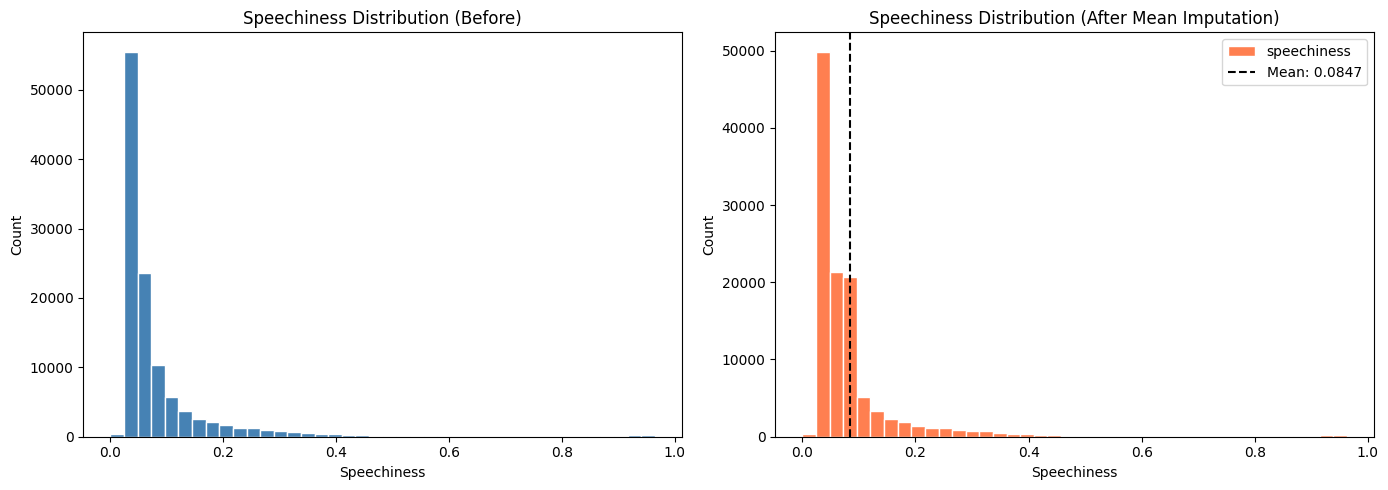

In [305]:
#Plot speechiness distribution before vs after imputation (full dataset)

# Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'speechiness']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Speechiness Distribution (Before)')
axes[0].set_xlabel('Speechiness')
axes[0].set_ylabel('Count')

df['speechiness'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(mean_speechiness, color='black', linestyle='--', label=f'Mean: {mean_speechiness:.4f}')
axes[1].set_title('Speechiness Distribution (After Mean Imputation)')
axes[1].set_xlabel('Speechiness')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()